# Predicting clinical trial duration

## The question

How long will a clinical trial take, using only what is known when it is
registered?

The constraint is the whole problem. Someone asking this question has not run
the trial yet, so only registration-time fields are legitimate features.
Anything recorded during or after the trial would leak the answer. AACT makes
the audit mostly mechanical: `Design_*` tables hold registration-time
information, `Result_*` tables hold post-completion information.

Target is `log(duration_days)`, measured from `start_date` to
`primary_completion_date`.

`primary_completion_date` rather than `completion_date`. ClinicalTrials.gov
defines primary completion as the point where data collection finishes for the
*primary* outcome; study completion is the later point where collection also
finishes for secondary outcomes and adverse events. Secondary and adverse-event
follow-up can run well past the end of the intervention, so `completion_date`
would measure reporting obligations rather than trial length.

Definitions: https://clinicaltrials.gov/policy/protocol-definitions

## Why it matters

First and foremost, a trial that runs too long delays the treatment reaching the people who need it.

There are also financial pressures to consider. Trial delays are a huge cost
line in pharmaceutical R&D: underestimating duration means the sponsor has to
find more money partway through, while overestimating means more funds are
reserved than necessary — money that could have gone toward developing other
drugs that could benefit other groups of people.

## The data

AACT (Aggregate Analysis of ClinicalTrials.gov) -- A public
relational PostgreSQL database of tables containing information about clinical
trials. Maintained by the Clinical Trials Transformation Initiative (CTTI), a
partnership between the FDA and Duke University. Content is refreshed daily
from ClinicalTrials.gov.

https://aact.ctti-clinicaltrials.org/

https://aact.ctti-clinicaltrials.org/schema

Seven tables are used here. Filters: interventional studies only, completed
status only, both dates present, primary completion after 2007 — post-FDAAA,
when reporting requirements tightened and date precision improved.

Because the database refreshes daily, results drift between runs. As a result, re-running the query may produce slightly different figures which is why this is mounted for August 21, 2026.

**Survivorship bias.** Only completed trials have an end date, so terminated
trials and trials still running past expectation are both invisible here.
Estimates skew optimistic. The model answers "conditional on this trial
completing, how long will it take?" — not "will it complete?"

CTTI asks that the source be acknowledged when its materials are used:
Aggregate Analysis of ClinicalTrials.gov (AACT) Database. Clinical Trials Transformation Initiative (CTTI). Available at: https://aact.ctti-clinicaltrials.org/ (Accessed: August 2026)


In [ ]:
pip install psycopg2-binary sqlalchemy

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt

# AACT requires a free account: https://aact.ctti-clinicaltrials.org/users/sign_up
USER = ""
PASSWORD = ""

engine = create_engine(
    f"postgresql+psycopg2://{USER}:{PASSWORD}"
    "@aact-db.ctti-clinicaltrials.org:5432/aact"
)

def q(sql):
    return pd.read_sql(sql, engine)

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

# The extraction is cached to Drive. AACT refreshes daily, so re-querying would
# shift every number in this notebook. First run queries and saves; every run
# after loads the same snapshot.
SAVE_DIR = '/content/drive/MyDrive'   # change if not running in Colab
PATH = f'{SAVE_DIR}/aact_extract_2026-08-21.parquet'

sql = """
SELECT s.nct_id,
s.start_date,
s.primary_completion_date,
s.phase,
s.enrollment,
s.enrollment_type,
s.number_of_arms,
s.is_fda_regulated_device,
s.is_fda_regulated_drug,
s.has_dmc,
s.source,
d.allocation,
d.intervention_model,
d.primary_purpose,
d.masking,
e.gender,
e.healthy_volunteers,
cv.minimum_age_num,
cv.minimum_age_unit,
cv.maximum_age_num,
cv.maximum_age_unit,
cv.number_of_facilities,
cv.has_us_facility,
cv.has_single_facility,
cv.registered_in_calendar_year,
cv.number_of_primary_outcomes_to_measure,
cv.number_of_secondary_outcomes_to_measure,
cv.number_of_other_outcomes_to_measure,
sp.agency_class AS lead_agency_class,
COALESCE(col.n_collaborators, 0) AS n_collaborators,
COALESCE(iv.n_interventions, 0) AS n_interventions,
COALESCE(cond.n_conditions, 0) AS n_conditions
FROM studies s
LEFT JOIN designs d
on s.nct_id = d.nct_id
LEFT JOIN eligibilities e
on s.nct_id = e.nct_id
LEFT JOIN calculated_values cv
on s.nct_id = cv.nct_id
LEFT JOIN (
    SELECT nct_id, agency_class
    FROM sponsors
    WHERE lead_or_collaborator = 'lead'
) sp
on s.nct_id = sp.nct_id
LEFT JOIN (
    SELECT nct_id, COUNT(*) AS n_collaborators
    FROM sponsors
    WHERE lead_or_collaborator = 'collaborator'
    GROUP BY nct_id
) col
on s.nct_id = col.nct_id
LEFT JOIN (
    SELECT nct_id, COUNT(*) AS n_interventions
    FROM interventions
    GROUP BY nct_id
) iv
on s.nct_id = iv.nct_id
LEFT JOIN (
    SELECT nct_id, COUNT(*) AS n_conditions
    FROM conditions
    GROUP BY nct_id
) cond
on s.nct_id = cond.nct_id
WHERE s.study_type = 'INTERVENTIONAL'
and s.overall_status = 'COMPLETED'
and s.start_date is NOT NULL
and s.primary_completion_date is NOT NULL
and s.primary_completion_date > '2007-12-31'
"""

if os.path.exists(PATH):
    raw = pd.read_parquet(PATH)
    print(f"loaded cached extract from {PATH}")
else:
    raw = q(sql)
    raw.to_parquet(PATH)
    print(f"queried AACT and saved to {PATH}")

print(raw.shape)
print(raw.isna().sum().sort_values(ascending=False))
raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loaded cached extract from /content/drive/MyDrive/aact_extract_2026-08-21.parquet
(229930, 32)
number_of_other_outcomes_to_measure        208830
is_fda_regulated_device                    103872
is_fda_regulated_drug                      103857
maximum_age_num                             95183
maximum_age_unit                            95183
number_of_secondary_outcomes_to_measure     50060
has_dmc                                     29115
has_us_facility                             12109
has_single_facility                         12109
minimum_age_num                              9487
minimum_age_unit                             9487
primary_purpose                              3933
number_of_arms                               3263
allocation                                    795
masking                                       740
intervention_model        

,nct_id,start_date,primary_completion_date,phase,enrollment,enrollment_type,number_of_arms,is_fda_regulated_device,is_fda_regulated_drug,has_dmc,...,has_us_facility,has_single_facility,registered_in_calendar_year,number_of_primary_outcomes_to_measure,number_of_secondary_outcomes_to_measure,number_of_other_outcomes_to_measure,lead_agency_class,n_collaborators,n_interventions,n_conditions
0,NCT00001379,1995-05-05,2025-01-17,PHASE2,94.0,ACTUAL,2.0,False,True,False,...,True,True,1999,2.0,1.0,1.0,NIH,0,10,4
1,NCT00002874,1998-02-28,2015-08-31,PHASE3,840.0,ACTUAL,2.0,None,None,True,...,True,False,1999,1.0,8.0,NaN,NETWORK,3,3,1
2,NCT00002975,1997-02-28,2009-04-30,PHASE2,180.0,ACTUAL,1.0,None,None,True,...,True,True,1999,1.0,NaN,NaN,OTHER,1,1,2
3,NCT00003199,1997-11-30,2009-12-31,PHASE2,50.0,ACTUAL,1.0,None,None,False,...,True,True,1999,1.0,2.0,NaN,OTHER,1,8,8
4,NCT00003537,1995-04-30,2008-10-31,PHASE2,19.0,ACTUAL,1.0,None,None,False,...,True,True,1999,1.0,1.0,NaN,OTHER,0,1,1


In [ ]:
print(raw.dtypes)

nct_id                                      object
start_date                                  object
primary_completion_date                     object
phase                                       object
enrollment                                 float64
enrollment_type                             object
number_of_arms                             float64
is_fda_regulated_device                     object
is_fda_regulated_drug                       object
has_dmc                                     object
source                                      object
allocation                                  object
intervention_model                          object
primary_purpose                             object
masking                                     object
gender                                      object
healthy_volunteers                          object
minimum_age_num                            float64
minimum_age_unit                            object
maximum_age_num                

Seven tables, eight joins — `sponsors` is used twice.

Four join directly, because they hold one row per trial:

- `studies` — the base table: dates, phase, enrollment, status
- `designs` — allocation, masking, intervention model, primary purpose
- `eligibilities` — gender, healthy volunteers
- `calculated_values` — AACT's own derived fields

Three are one-to-many: a single trial can have many conditions, many
interventions, and many collaborators. Joining those directly would multiply
rows — a trial with five conditions would appear five times, and every
per-trial number after that would be wrong. So each is collapsed to one row
per trial in a subquery first, using `GROUP BY nct_id` with `COUNT(*)`, and
only then joined.

The `sponsors` table is used twice for two different reasons: one subquery
filters to the lead sponsor to get `agency_class`, and another counts
collaborators. The first is a filter rather than an aggregate, because there
is exactly one lead per trial — verified below, since if it weren't true the
subquery would duplicate rows silently.

`calculated_values` was worth finding. It supplies pre-parsed ages
(`minimum_age_num` / `minimum_age_unit`), `number_of_facilities`,
`has_us_facility`, `has_single_facility`, `registered_in_calendar_year`, and
planned outcome counts which prevented having to perform manual string parsing.

`LEFT JOIN` throughout, so a trial with no collaborators or no listed
conditions is kept rather than dropped. `COALESCE(..., 0)` turns the resulting
nulls into zeros, which is the correct reading: no matching rows means none of
that thing exists.

In [ ]:
cols = ['number_of_arms','enrollment_type','enrollment','phase','allocation',
        'masking','intervention_model','primary_purpose','healthy_volunteers','gender']
print((raw[cols].isna().mean() * 100).round(2).sort_values(ascending=False))

primary_purpose       1.71
number_of_arms        1.42
allocation            0.35
masking               0.32
intervention_model    0.27
enrollment_type       0.11
enrollment            0.09
healthy_volunteers    0.08
gender                0.05
phase                 0.04
dtype: float64


In [ ]:
df = raw.copy()
# 45% null, and the missingness proxies for registration era (these fields were
# added to the registry later) — registered_in_calendar_year captures that directly
df = df.drop(columns = ['is_fda_regulated_device', 'is_fda_regulated_drug'])

# All ten columns are under 2% null. We drop the
# rows rather than imputing because filling a mode for a design field would invent a
# decision the investigators never made so we don't want to make any assumptions.
df = df.dropna(subset=['number_of_arms', 'enrollment_type', 'enrollment', 'phase', 'allocation', 'masking', 'intervention_model', 'primary_purpose', 'healthy_volunteers', 'gender'])
df['start_date'] = pd.to_datetime(df['start_date'])
df['primary_completion_date'] = pd.to_datetime(df['primary_completion_date'])
df['duration_days'] = (df['primary_completion_date'] - df['start_date']).dt.days

# A handful of records have completion before start.
df = df[df['duration_days'] > 0]
# 13% null, kept as a three-way dummy rather than dropped. Unlike the FDA columns
# above, "did not report a monitoring committee" is plausibly informative for our model.
df = pd.get_dummies(df, columns = ['has_dmc'], dummy_na=True)
print(df.isna().sum().sort_values(ascending=False))
print(df.shape)


number_of_other_outcomes_to_measure        199785
maximum_age_unit                            91464
maximum_age_num                             91464
number_of_secondary_outcomes_to_measure     47165
has_us_facility                             11231
has_single_facility                         11231
minimum_age_unit                             8908
minimum_age_num                              8908
number_of_primary_outcomes_to_measure         156
nct_id                                          0
source                                          0
allocation                                      0
start_date                                      0
enrollment_type                                 0
primary_completion_date                         0
phase                                           0
enrollment                                      0
healthy_volunteers                              0
primary_purpose                                 0
masking                                         0


In [ ]:
print(f"rows lost: {len(raw) - len(df)}")

rows lost: 9454


In [ ]:
display(df['minimum_age_unit'].value_counts())
display(df['maximum_age_unit'].value_counts())


mapping = {
    "year": 1,
    "month": 1/12,
    "week": 1/52.18,
    "day": 1/365.25,
    "hour": 1/8766,
    "minute": 1/525960,
}


df['min_map'] = df['minimum_age_unit'].map(mapping)
df['max_map'] = df['maximum_age_unit'].map(mapping)
#perform multiplication to get into years only
df['min_age_years'] = df['minimum_age_num'] * df['min_map']
df['max_age_years'] = df['maximum_age_num'] * df['max_map']

# both nulls are structural according to AACT
df['min_age_years'] =  df['min_age_years'].fillna(0) # no lower limit
df['has_max_age'] = np.where(df["max_age_years"].isna(), 0, 1)
df['max_age_years'] =  df['max_age_years'].fillna(120) #no upper limit

df = df.drop(columns=['min_map', 'max_map',
                      'minimum_age_num', 'minimum_age_unit',
                      'maximum_age_num', 'maximum_age_unit'])







,count
minimum_age_unit,
year,205793
month,3436
day,1152
week,824
hour,226
minute,137


,count
maximum_age_unit,
year,124850
month,2169
day,929
week,782
hour,234
minute,48


In [ ]:
# 0 sites for a completed trial makes no logical sense. Instead
# of dropping, we flag it as number_of_facilites yes or no.
zero_fac = df[df['number_of_facilities'] == 0]
print(len(zero_fac))
df['has_facility_data'] = np.where(df['number_of_facilities'] == 0, 0, 1)
df['has_us_facility'] = df['has_us_facility'].fillna(False).astype(int)
df['has_single_facility'] = df['has_single_facility'].fillna(False).astype(int)


11231


/tmp/ipykernel_669/4027025312.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_us_facility'] = df['has_us_facility'].fillna(False).astype(int)
/tmp/ipykernel_669/4027025312.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_single_facility'] = df['has_single_facility'].fillna(False).astype(int)


In [ ]:
display(df['number_of_secondary_outcomes_to_measure'].value_counts())
display(df['number_of_other_outcomes_to_measure'].value_counts())

# null = trial declared none of that type
df['number_of_secondary_outcomes_to_measure'] = df['number_of_secondary_outcomes_to_measure'].fillna(0)
df['number_of_other_outcomes_to_measure'] = df['number_of_other_outcomes_to_measure'].fillna(0)

print(df.isna().sum().sort_values(ascending=False).head(10))
print(df.shape)
# every trial must have a primary outcome, so null there is truly missing
df = df.dropna(subset=['number_of_primary_outcomes_to_measure'])
print(df.isna().sum().sort_values(ascending=False).head(10))
print(df.shape)

,count
number_of_secondary_outcomes_to_measure,
1.0,39475
2.0,25015
3.0,21250
4.0,17620
5.0,13525
...,...
118.0,1
208.0,1
170.0,1


,count
number_of_other_outcomes_to_measure,
1.0,7647
2.0,3668
3.0,2348
4.0,1748
5.0,1092
...,...
68.0,1
66.0,1
55.0,1


number_of_primary_outcomes_to_measure    156
nct_id                                     0
start_date                                 0
phase                                      0
primary_completion_date                    0
enrollment_type                            0
number_of_arms                             0
source                                     0
enrollment                                 0
intervention_model                         0
dtype: int64
(220476, 33)
nct_id                     0
start_date                 0
primary_completion_date    0
phase                      0
enrollment                 0
enrollment_type            0
number_of_arms             0
source                     0
allocation                 0
intervention_model         0
dtype: int64
(220320, 33)


longest recorded duration: 38,114 days (104 years)


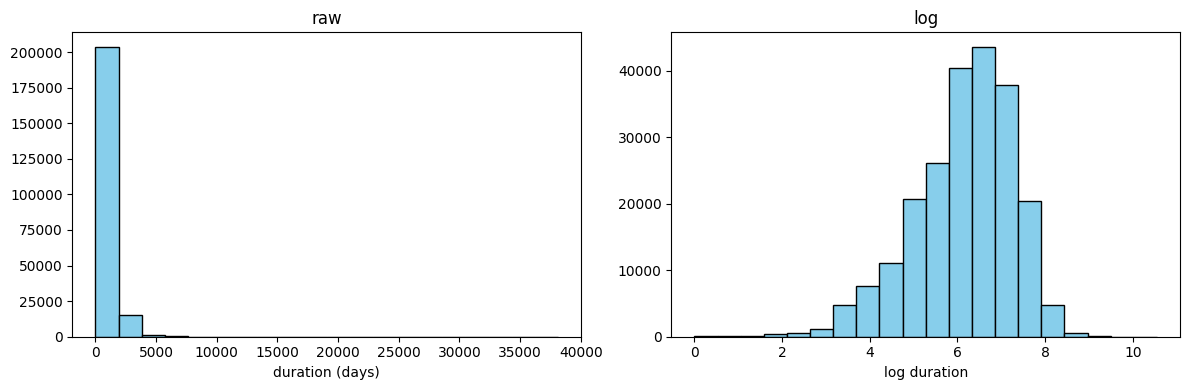

In [ ]:
print(f"longest recorded duration: {df['duration_days'].max():,} days "
      f"({df['duration_days'].max()/365.25:.0f} years)")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(df['duration_days'], bins=20, color='skyblue', edgecolor='black')
ax[0].set_xlabel('duration (days)')
ax[0].set_title('raw')

ax[1].hist(np.log(df['duration_days']), bins=20, color='skyblue', edgecolor='black')
ax[1].set_xlabel('log duration')
ax[1].set_title('log')

plt.tight_layout()
plt.show()

df['log_duration'] = np.log(df['duration_days'])

We apply a log transformation since duration is heavily right-skewed in raw
days. It also makes extreme outliers more tolerable — the longest record is
38,114 days, which is not a real trial, but in log units it stops dominating
the loss.

In [ ]:
df['log_duration']

,log_duration
0,9.291920
1,8.762959
2,8.399310
3,8.392537
4,8.503703
...,...
229925,6.593045
229926,6.882437
229927,6.246107
229928,6.188264


In [ ]:
cats = ['phase', 'lead_agency_class', 'primary_purpose', 'masking',
        'allocation', 'intervention_model', 'gender', 'healthy_volunteers']

for col in cats:
    print(col)
    print(df[col].value_counts())
    print()

phase
phase
NA               119492
PHASE2            26688
PHASE1            25663
PHASE3            19617
PHASE4            17035
PHASE1/PHASE2      6173
PHASE2/PHASE3      3188
EARLY_PHASE1       2464
Name: count, dtype: int64

lead_agency_class
lead_agency_class
OTHER        148968
INDUSTRY      60414
OTHER_GOV      4599
NIH            2456
FED            2250
NETWORK        1401
INDIV           200
UNKNOWN          30
AMBIG             2
Name: count, dtype: int64

primary_purpose
primary_purpose
TREATMENT                   132511
PREVENTION                   26197
OTHER                        15327
SUPPORTIVE_CARE              14109
BASIC_SCIENCE                13584
DIAGNOSTIC                    8696
HEALTH_SERVICES_RESEARCH      6997
SCREENING                     2104
DEVICE_FEASIBILITY             795
Name: count, dtype: int64

masking
masking
NONE         114439
SINGLE        36699
DOUBLE        30542
QUADRUPLE     22401
TRIPLE        16239
Name: count, dtype: int64

allocatio

Only `lead_agency_class` has a class imbalance problem: AMBIG (2 rows),
UNKNOWN (30), and INDIV (200). We drop them rather than folding them into
OTHER, since they are genuinely different sponsor types and merging would be
misleading. 232 rows total, so the cost is negligible. Every other category
across all eight features has at least 795 rows.

One thing to note regarding `phase` and N/A

- `phase` — 119,492 rows, 54% of the data. Per the ClinicalTrials.gov
  definitions, N/A means a trial without phases, such as a device or
  behavioural study. The phase system doesn't apply to them. Dropping these
  would cost half the dataset.


In [ ]:
before = len(df)
df = df[~df['lead_agency_class'].isin(['AMBIG', 'UNKNOWN', 'INDIV'])]
print(f"dropped {before - len(df)} rows")
print(df.shape)

dropped 232 rows
(220088, 34)


In [ ]:
for col in cats:
    print(col)
    detail = df.groupby(col).agg(
        median_days=('duration_days', 'median'),
        std_log=('log_duration', 'std'),
        count=('duration_days', 'count'),
    ).sort_values('median_days')
    print(detail.round(2))
    print()

rows = []
for col in cats:
    med = df.groupby(col)['duration_days'].median()
    std = df.groupby(col)['log_duration'].std()
    cnt = df.groupby(col)['duration_days'].count()
    rows.append({
        'feature': col,
        'n_categories': len(med),
        'smallest_category': cnt.min(),
        'median_low': med.min(),
        'median_high': med.max(),
        'ratio': round(med.max() / med.min(), 1),
        'std_low': round(std.min(), 2),
        'std_high': round(std.max(), 2),
    })

summary = pd.DataFrame(rows).sort_values('ratio', ascending=False).reset_index(drop=True)
print("Overall std of log_duration:", round(df['log_duration'].std(), 2))
summary

phase
               median_days  std_log   count
phase                                      
PHASE1               308.0     1.33   25639
NA                   458.0     1.14  119415
EARLY_PHASE1         580.5     1.06    2460
PHASE4               640.0     0.97   16981
PHASE2/PHASE3        701.0     0.93    3180
PHASE3               724.0     0.93   19609
PHASE2               792.0     0.93   26642
PHASE1/PHASE2        915.0     0.95    6162

lead_agency_class
                   median_days  std_log   count
lead_agency_class                              
INDUSTRY                 425.0     1.17   60414
OTHER_GOV                488.0     1.09    4599
OTHER                    579.0     1.11  148968
FED                     1037.0     0.85    2250
NETWORK                 1124.0     1.16    1401
NIH                     1369.0     0.80    2456

primary_purpose
                          median_days  std_log   count
primary_purpose                                       
OTHER                   

,feature,n_categories,smallest_category,median_low,median_high,ratio,std_low,std_high
0,lead_agency_class,6,1401,425.0,1369.0,3.2,0.80,1.17
1,phase,8,2460,308.0,915.0,3.0,0.93,1.33
2,intervention_model,5,3170,245.0,669.0,2.7,1.06,1.27
3,healthy_volunteers,2,71675,304.0,678.0,2.2,0.99,1.24
4,primary_purpose,9,795,308.0,628.0,2.0,1.08,1.30
5,gender,3,11068,306.0,549.0,1.8,1.10,1.35
6,masking,5,16207,426.0,623.0,1.5,0.97,1.19
7,allocation,3,20805,493.0,669.0,1.4,1.12,1.19


These features are useful for predicting the median duration — the ratios range
from 1.4x (allocation) to 3.2x (lead_agency_class), so knowing the category
meaningfully shifts the expected value.

But the standard deviation within each category is similar to the overall
standard deviation (1.14 in log units, categories ranging 0.80 to 1.35).
Splitting by any of these features leaves roughly the same spread you started
with. A standard deviation of 1.14 is a factor of about 3 in days, so knowing
the category still leaves roughly 3x uncertainty either way.

This is the central finding of the EDA, and it shapes what the models can do.
Every categorical feature moves the centre; none of them narrows the range.
Whatever accuracy the models reach, the honest output is an interval rather
than a point estimate.

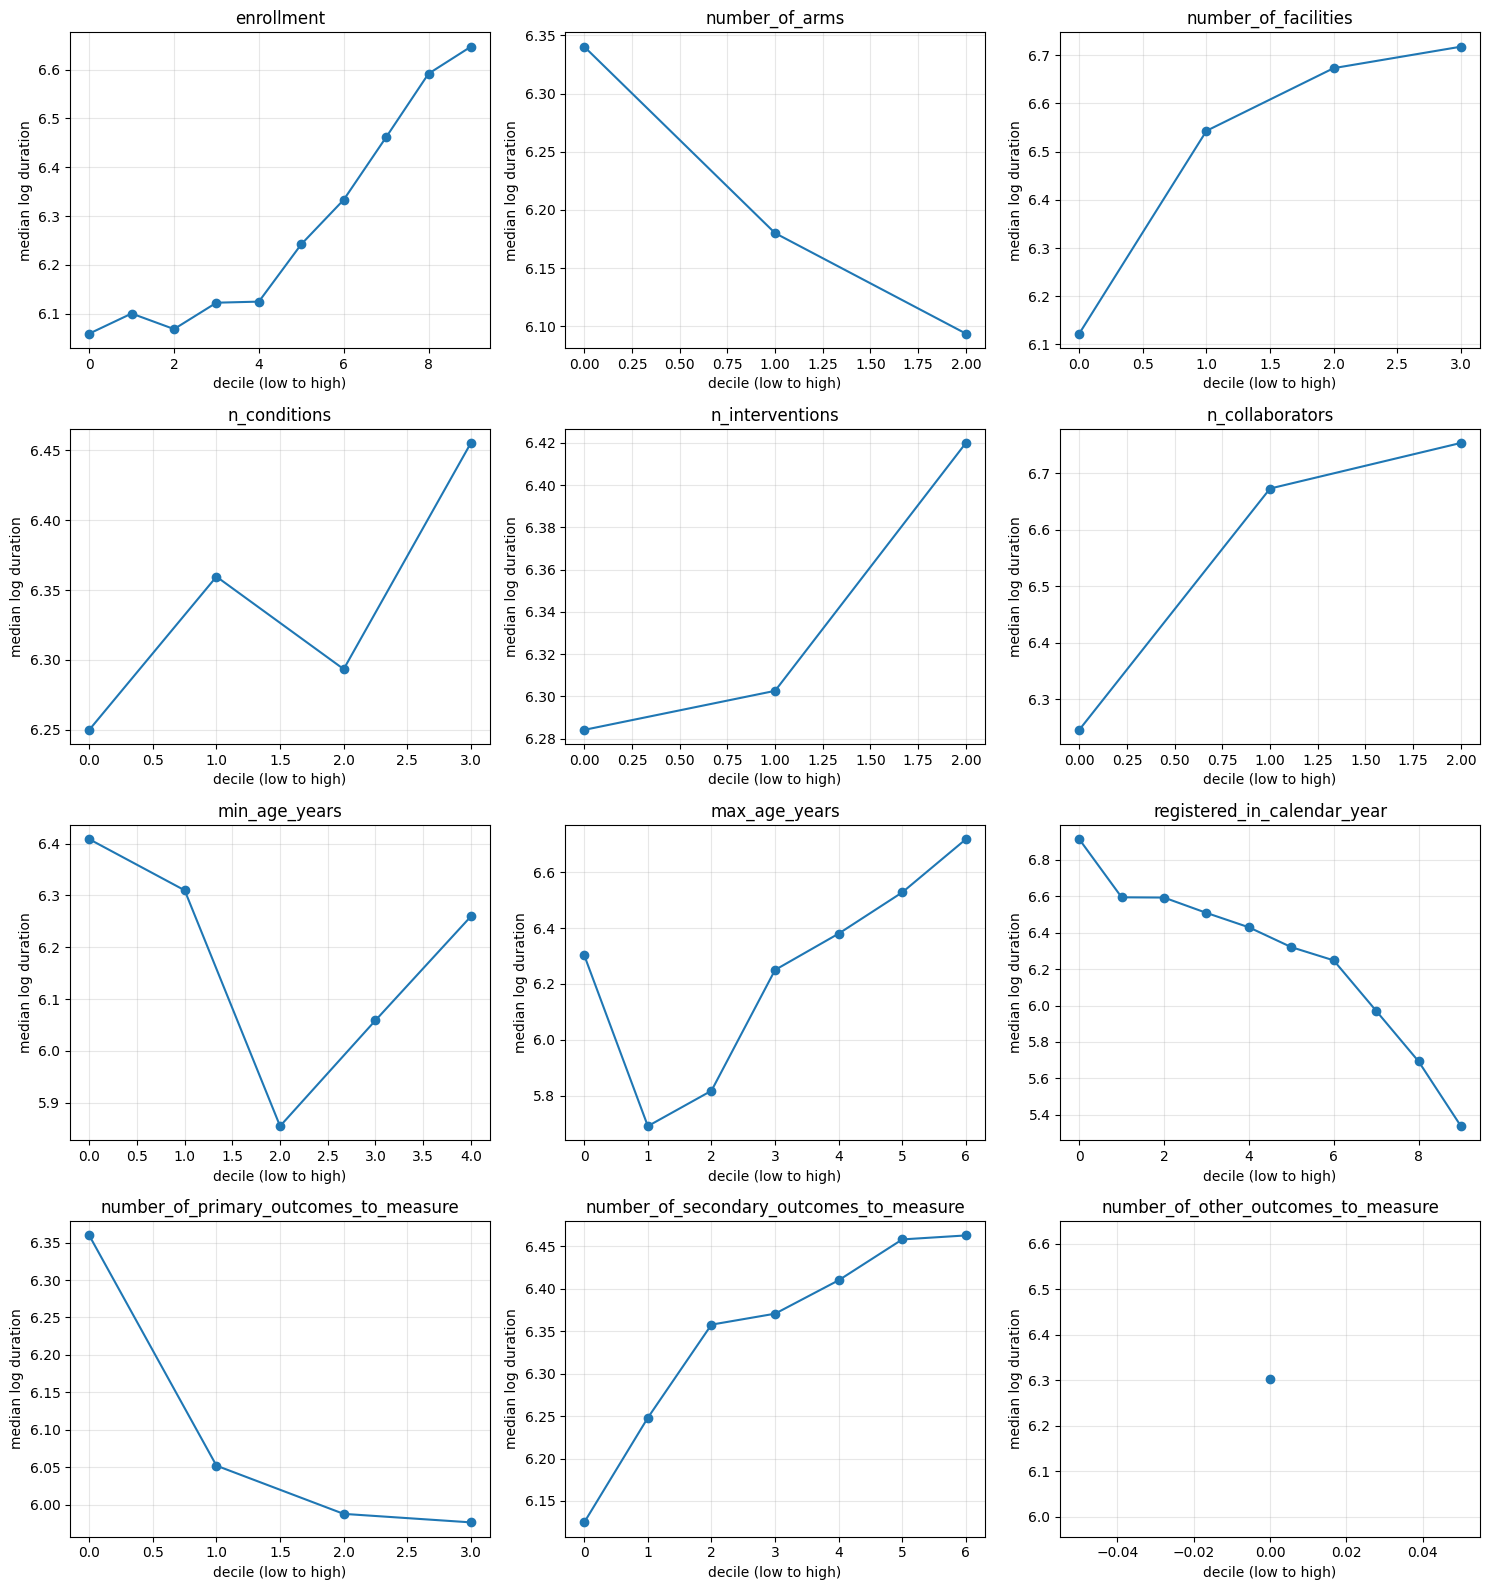

In [ ]:
nums = ['enrollment', 'number_of_arms', 'number_of_facilities',
        'n_conditions', 'n_interventions', 'n_collaborators',
        'min_age_years', 'max_age_years', 'registered_in_calendar_year',
        'number_of_primary_outcomes_to_measure',
        'number_of_secondary_outcomes_to_measure',
        'number_of_other_outcomes_to_measure']

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for col, ax in zip(nums, axes.flatten()):
    # split the feature into 10 equal-sized groups, take median duration in each
    bins = pd.qcut(df[col], 10, duplicates='drop')
    binned = df.groupby(bins, observed=True)['log_duration'].median()

    ax.plot(range(len(binned)), binned.values, marker='o')
    ax.set_title(col)
    ax.set_xlabel('decile (low to high)')
    ax.set_ylabel('median log duration')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
display(df[nums].corr().round(2))

# median shift and within-bin spread for every numeric feature
for col in nums:
    bins = pd.qcut(df[col], 10, duplicates='drop')
    g = df.groupby(bins, observed=True)['log_duration']
    meds, stds = g.median(), g.std()
    print(f"{col:42s} median {np.exp(meds.max()-meds.min()):.1f}x   "
          f"std {stds.min():.2f} to {stds.max():.2f}")

print(f"\noverall std: {df['log_duration'].std():.2f}")

# outlier check — enrollment is far more skewed than anything else here
print(df[nums].agg(['median', 'max']).T.sort_values('max', ascending=False).head())

n_extreme = (df['enrollment'] > 100_000).sum()
print(f"enrollment above 100,000: {n_extreme} rows ({n_extreme/len(df)*100:.2f}%)")

# enrollment specifically, since it has the most bins and the clearest trend
bins = pd.qcut(df['enrollment'], 10, duplicates='drop')
print(df.groupby(bins, observed=True)['log_duration'].agg(['median', 'std']))

,enrollment,number_of_arms,number_of_facilities,n_conditions,n_interventions,n_collaborators,min_age_years,max_age_years,registered_in_calendar_year,number_of_primary_outcomes_to_measure,number_of_secondary_outcomes_to_measure,number_of_other_outcomes_to_measure
enrollment,1.00,0.01,0.00,0.00,-0.00,0.01,-0.01,0.00,0.00,-0.00,-0.00,0.01
number_of_arms,0.01,1.00,0.06,-0.03,0.40,0.00,0.01,-0.09,0.02,0.10,0.09,0.01
number_of_facilities,0.00,0.06,1.00,0.00,0.13,-0.01,0.01,0.10,-0.11,-0.01,0.14,0.01
n_conditions,0.00,-0.03,0.00,1.00,0.06,0.04,-0.01,0.04,0.03,0.02,0.01,0.03
n_interventions,-0.00,0.40,0.13,0.06,1.00,0.01,0.00,-0.02,-0.10,0.04,0.09,0.01
n_collaborators,0.01,0.00,-0.01,0.04,0.01,1.00,-0.00,0.03,-0.05,-0.00,0.06,0.08
min_age_years,-0.01,0.01,0.01,-0.01,0.00,-0.00,1.00,0.25,0.02,0.01,0.02,0.03
max_age_years,0.00,-0.09,0.10,0.04,-0.02,0.03,0.25,1.00,-0.10,-0.06,0.05,0.02
registered_in_calendar_year,0.00,0.02,-0.11,0.03,-0.10,-0.05,0.02,-0.10,1.00,0.12,0.01,0.05
number_of_primary_outcomes_to_measure,-0.00,0.10,-0.01,0.02,0.04,-0.00,0.01,-0.06,0.12,1.00,0.09,0.01


enrollment                                 median 1.8x   std 0.98 to 1.26
number_of_arms                             median 1.3x   std 1.13 to 1.14
number_of_facilities                       median 1.8x   std 0.76 to 1.18
n_conditions                               median 1.2x   std 1.10 to 1.15
n_interventions                            median 1.1x   std 1.13 to 1.17
n_collaborators                            median 1.7x   std 0.96 to 1.15
min_age_years                              median 1.7x   std 1.05 to 1.33
max_age_years                              median 2.8x   std 0.78 to 1.21
registered_in_calendar_year                median 4.8x   std 0.99 to 1.09
number_of_primary_outcomes_to_measure      median 1.5x   std 1.12 to 1.22
number_of_secondary_outcomes_to_measure    median 1.4x   std 0.97 to 1.23
number_of_other_outcomes_to_measure        median 1.0x   std 1.14 to 1.14

overall std: 1.14
                                         median         max
enrollment                       

## Numeric features

Binned into deciles with `qcut`, then median `log_duration` per bin. Features
with few distinct values give few bins, so those shape claims are weaker. The
multiplier after each one is how much the median duration shifts from the
lowest decile to the highest.

- **`enrollment`** — 1.8x. 10 points. Increase, dip, plateau, then sharp rise. Nonlinear.
- **`number_of_arms`** — 1.3x. 3 points, looks linear.
- **`number_of_facilities`** — 1.8x. 4 points, seems to plateau. Concave down.
- **`min_age_years`** — 1.7x, **`max_age_years`** — 2.8x. 5 and 7 points, both U-shaped. Quadratic.
- **`registered_in_calendar_year`** — 4.8x, the largest here. 10 points, clean negative linear.
- **`number_of_primary_outcomes_to_measure`** — 1.5x. 4 points, maybe a plateau.
- **`number_of_secondary_outcomes_to_measure`** — 1.4x. Clearly linear.
- **`number_of_other_outcomes_to_measure`** — 1.0x, one bin, no signal. Dropped below.
- **`n_conditions`** — 1.2x. 4 points, concavity changes, so possibly nonlinear.
- **`n_interventions`** — 1.1x. 3 points, always rising. Could be linear or not.
- **`n_collaborators`** — 1.7x. 3 points, sharp rise then plateau.

Same spread picture as the categoricals: within-bin standard deviations run
0.76 to 1.33 across all twelve features, against an overall 1.14. The median
shifts, the spread doesn't.

Enrollment also has a crazy range. Median 60, max 20,121,212, which is a date
(2012-12-12) typed into a numeric field. 146 rows report enrollment above
100,000, and nothing else here is close to that skewed. We try a log transform
on this feature later to compress the scale. The other features aren't worth
logging since none of them span anything like that range.

**Feature dependency.** Strongest correlation is 0.40, most near 0. These
features aren't measuring the same underlying thing meaning that they carry
independent information.

In [ ]:
print(df.columns.tolist())

['nct_id', 'start_date', 'primary_completion_date', 'phase', 'enrollment', 'enrollment_type', 'number_of_arms', 'source', 'allocation', 'intervention_model', 'primary_purpose', 'masking', 'gender', 'healthy_volunteers', 'number_of_facilities', 'has_us_facility', 'has_single_facility', 'registered_in_calendar_year', 'number_of_primary_outcomes_to_measure', 'number_of_secondary_outcomes_to_measure', 'number_of_other_outcomes_to_measure', 'lead_agency_class', 'n_collaborators', 'n_interventions', 'n_conditions', 'duration_days', 'has_dmc_False', 'has_dmc_True', 'has_dmc_nan', 'min_age_years', 'max_age_years', 'has_max_age', 'has_facility_data', 'log_duration']


In [ ]:
# remove label + identifiers
y = df['log_duration']
X = df.drop(columns=['nct_id', 'start_date', 'primary_completion_date',
                     'duration_days', 'log_duration'])

# whatever isn't in nums or cats — these turn out to be the has_* flags,
# plus source and enrollment_type, which we drop below
other_features_to_consider = []
for elem in X.columns.tolist():
  if (elem not in nums) and (elem not in cats):
    other_features_to_consider.append(elem)
other_features_to_consider

# source has too many distinct values for one-hot encoding
print(df['source'].nunique())
print(df['source'].value_counts().head(10))

# at registration every trial's enrollment is anticipated since the ACTUAL label
# only appears after completion, so this column has no variation in the
# situation we're predicting for. Sponsors overwrite it on completion and AACT
# keeps only the current value, so the registration-time value is unrecoverable.
print(df['enrollment_type'].value_counts())
print(df.groupby('enrollment_type')['duration_days'].agg(['median', 'count']))

# 91% zeros, qcut produced a single bin — no variation to learn from
print((df['number_of_other_outcomes_to_measure'] == 0).mean())

X = X.drop(columns=['source', 'enrollment_type',
                    'number_of_other_outcomes_to_measure'])

print(X.shape)
print(X.dtypes.value_counts())

17945
source
GlaxoSmithKline                          1972
Novartis                                 1752
Pfizer                                   1616
Cairo University                         1601
Mayo Clinic                              1364
AstraZeneca                              1343
Eli Lilly and Company                    1341
Riphah International University          1253
VA Office of Research and Development    1233
Sanofi                                   1171
Name: count, dtype: int64
enrollment_type
ACTUAL       216308
ESTIMATED      3780
Name: count, dtype: int64
                 median   count
enrollment_type                
ACTUAL            545.0  216308
ESTIMATED         699.0    3780
0.9060830213369198
(220088, 26)
int64      9
object     8
float64    6
bool       3
Name: count, dtype: int64


### A note on `enrollment`

`enrollment_type` gets dropped above because it fails the day-one test. At
registration every trial's enrollment is anticipated, so the ACTUAL label only
appears after completion.

The same problem touches `enrollment` itself, more mildly. For completed
trials this is the actual final count, not the planned figure. Sponsors
overwrite the value on completion and AACT keeps only the current version, so
the registration-time number is unrecoverable. That means it partly reflects
how recruitment went: a trial that struggled to recruit both under-enrolled
and ran long.

It stays anyway. Most of what the column carries is intended scale, which is a
legitimate design choice known at registration, however I did want to acknowkledge that it isn't strictly a registration-time value.

In [ ]:
X = pd.get_dummies(X).astype(float)
print(X.shape)
print(X.dtypes.value_counts())
X

(220088, 59)
float64    59
Name: count, dtype: int64


,enrollment,number_of_arms,number_of_facilities,has_us_facility,has_single_facility,registered_in_calendar_year,number_of_primary_outcomes_to_measure,number_of_secondary_outcomes_to_measure,n_collaborators,n_interventions,...,gender_FEMALE,gender_MALE,healthy_volunteers_False,healthy_volunteers_True,lead_agency_class_FED,lead_agency_class_INDUSTRY,lead_agency_class_NETWORK,lead_agency_class_NIH,lead_agency_class_OTHER,lead_agency_class_OTHER_GOV
0,94.0,2.0,1.0,1.0,1.0,1999.0,2.0,1.0,0.0,10.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,840.0,2.0,240.0,1.0,0.0,1999.0,1.0,8.0,3.0,3.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,180.0,1.0,1.0,1.0,1.0,1999.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,50.0,1.0,1.0,1.0,1.0,1999.0,1.0,2.0,1.0,8.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,19.0,1.0,1.0,1.0,1.0,1999.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229924,105.0,3.0,1.0,1.0,1.0,2009.0,1.0,0.0,0.0,3.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
229925,187.0,2.0,16.0,0.0,0.0,2009.0,1.0,6.0,0.0,2.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
229926,195.0,3.0,31.0,0.0,0.0,2009.0,1.0,15.0,0.0,3.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
229928,59.0,3.0,2.0,1.0,0.0,2009.0,1.0,3.0,0.0,3.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# hold out test first, then carve validation out of what's left
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)


(140856, 59) (35214, 59) (44018, 59)


In [ ]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(X_train_s.mean(axis=0).round(3))
print(X_train_s.std(axis=0).round(3))

[ 0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0.  0. -0.  0. -0.  0.  0.
 -0.  0. -0. -0. -0.  0. -0.  0.  0.  0. -0. -0. -0. -0.  0.  0.  0.  0.
 -0.  0.  0. -0.  0.  0.  0. -0.  0.  0. -0.  0. -0. -0. -0. -0. -0. -0.
 -0. -0.  0. -0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

results = {}

results['predict-the-mean'] = np.sqrt(mean_squared_error(
    y_test, np.full_like(y_test, y_train.mean())))

lin = LinearRegression().fit(X_train_s, y_train)
results['linear regression'] = np.sqrt(mean_squared_error(y_test, lin.predict(X_test_s)))

for k, v in results.items():
    print(f"{k:20s} {v:.4f}")

predict-the-mean     1.1317
linear regression    0.9160


Applying error formula: ( 1.1317 − 0.9160) /1.1317 = 0.19. We see a 19% improvement.

In [ ]:
X_poly = X.copy()
X_poly['min_age_sq'] = X_poly['min_age_years'] ** 2
X_poly['max_age_sq'] = X_poly['max_age_years'] ** 2

Xp_temp, Xp_test, yp_temp, yp_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42)
Xp_train, Xp_val, yp_train, yp_val = train_test_split(
    Xp_temp, yp_temp, test_size=0.2, random_state=42)

scaler_p = StandardScaler().fit(Xp_train)
Xp_train_s = scaler_p.transform(Xp_train)
Xp_test_s = scaler_p.transform(Xp_test)

lin_poly = LinearRegression().fit(Xp_train_s, yp_train)
results['linear + age²'] = np.sqrt(mean_squared_error(yp_test, lin_poly.predict(Xp_test_s)))
print(f"linear + age²        {results['linear + age²']:.4f}")

linear + age²        0.9141


Same 19% improvement, slightly better than basic linear regression.

In [ ]:
X_log = X.copy()
X_log['enrollment'] = np.log1p(X_log['enrollment'])

Xl_temp, Xl_test, yl_temp, yl_test = train_test_split(
    X_log, y, test_size=0.2, random_state=42)
Xl_train, Xl_val, yl_train, yl_val = train_test_split(
    Xl_temp, yl_temp, test_size=0.2, random_state=42)

scaler_l = StandardScaler().fit(Xl_train)
Xl_train_s = scaler_l.transform(Xl_train)
Xl_val_s = scaler_l.transform(Xl_val)
Xl_test_s = scaler_l.transform(Xl_test)

lin_log = LinearRegression().fit(Xl_train_s, yl_train)
results['linear + log(enrollment)'] = np.sqrt(mean_squared_error(yl_test, lin_log.predict(Xl_test_s)))
print(f"linear + log(enroll) {results['linear + log(enrollment)']:.4f}")

linear + log(enroll) 0.9086


Same 19% improvement, slightly better than basic linear regression and linear + age².

In [ ]:
X_both = X.copy()
X_both['enrollment'] = np.log1p(X_both['enrollment'])
X_both['min_age_sq'] = X['min_age_years'] ** 2
X_both['max_age_sq'] = X['max_age_years'] ** 2

Xb_temp, Xb_test, yb_temp, yb_test = train_test_split(
    X_both, y, test_size=0.2, random_state=42)
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    Xb_temp, yb_temp, test_size=0.2, random_state=42)

scaler_b = StandardScaler().fit(Xb_train)
Xb_train_s = scaler_b.transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)

lin_both = LinearRegression().fit(Xb_train_s, yb_train)
results['linear + log + age²'] = np.sqrt(mean_squared_error(yb_test, lin_both.predict(Xb_test_s)))
print(f"linear + log + age²  {results['linear + log + age²']:.4f}")

linear + log + age²  0.9070


Same 19% improvement, slightly better than basic linear regression, linear + age², and linear + log(enroll).

sklearn MLP          0.8765


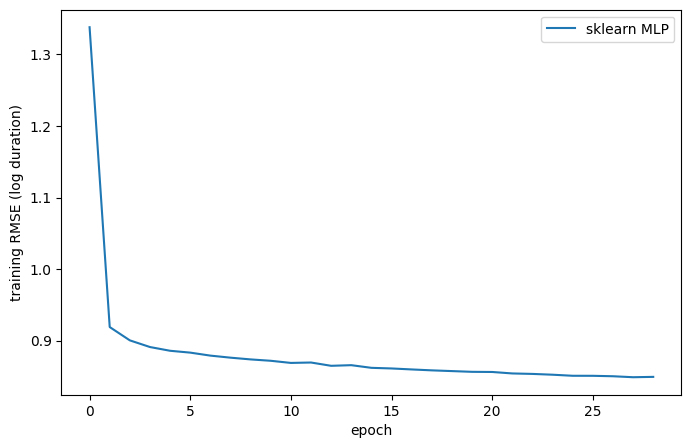

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=300,
                   early_stopping=True, random_state=42).fit(X_train_s, y_train)
results['sklearn MLP'] = np.sqrt(mean_squared_error(y_test, mlp.predict(X_test_s)))
print(f"sklearn MLP          {results['sklearn MLP']:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.sqrt(2 * np.array(mlp.loss_curve_)), label='sklearn MLP')
plt.xlabel('epoch')
plt.ylabel('training RMSE (log duration)')
plt.legend()
plt.show()

Applying error formula: ( 1.1317 − 0.8765) /1.1317 = 0.225. We see a 23% improvement over guessing the baseline and this is better than all of the prior linear based models.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


keras 0.8698


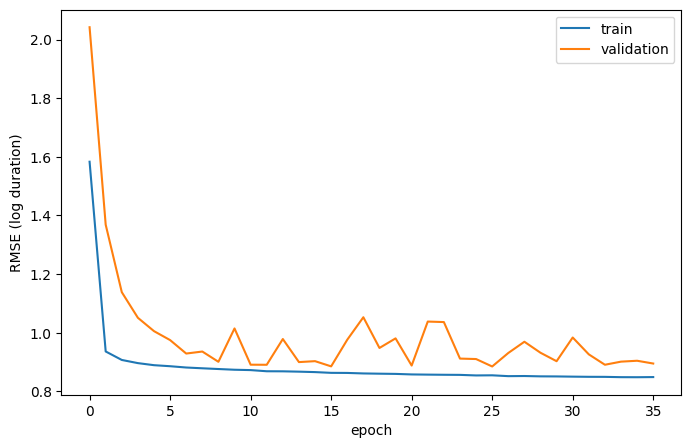

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
keras.layers.Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)),
keras.layers.Dense(64, activation='relu'),
keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train_s, y_train,
                    validation_data=(X_val_s, y_val),
                    epochs=50, batch_size=256, verbose=0,
                    callbacks=[keras.callbacks.EarlyStopping(
                        patience=10, restore_best_weights=True)])

results['keras'] = np.sqrt(mean_squared_error(y_test, model.predict(X_test_s, verbose=0).flatten()))
print(f"keras {results['keras']:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.sqrt(history.history['loss']), label='train')
plt.plot(np.sqrt(history.history['val_loss']), label='validation')
plt.xlabel('epoch')
plt.ylabel('RMSE (log duration)')
plt.legend()
plt.show()

Applying error formula: ( 1.1317 − 0.8698) /1.1317 = 0.23. We see a 23% improvement over guessing the baseline and this is better than all of the prior linear based models We see a strange spike, this can be explained by some of the huge numbers present in enrollment so we can take the log of enrollment to reduce this effect.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


val_loss range: 0.7538 to 0.9147
keras + log(enroll)  0.8653


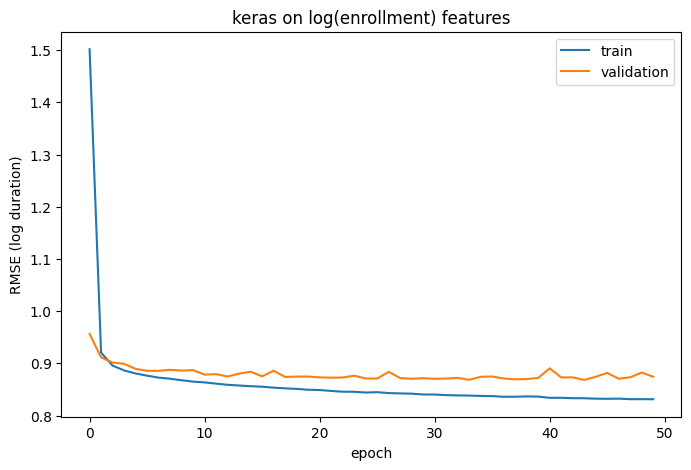

In [ ]:
model_log = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(Xl_train_s.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])
model_log.compile(optimizer='adam', loss='mse')

history_log = model_log.fit(Xl_train_s, yl_train,
                            validation_data=(Xl_val_s, yl_val),
                            epochs=50, batch_size=256, verbose=0)

print(f"val_loss range: {min(history_log.history['val_loss']):.4f} "
      f"to {max(history_log.history['val_loss']):.4f}")

results['keras + log(enroll)'] = np.sqrt(mean_squared_error(
    yl_test, model_log.predict(Xl_test_s, verbose=0).flatten()))
print(f"keras + log(enroll)  {results['keras + log(enroll)']:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.sqrt(history_log.history['loss']), label='train')
plt.plot(np.sqrt(history_log.history['val_loss']), label='validation')
plt.xlabel('epoch')
plt.ylabel('RMSE (log duration)')
plt.title('keras on log(enrollment) features')
plt.legend()
plt.show()

Applying error formula: ( 1.1317 − 0.8653) /1.1317 = 0.235. We see a 24% improvement over guessing the baseline and this is better than all of the prior linear based models and the other neural networks.

(59, 140856) (1, 140856)
18.021898053065957 0.4157744406182369 0.9118930207192474


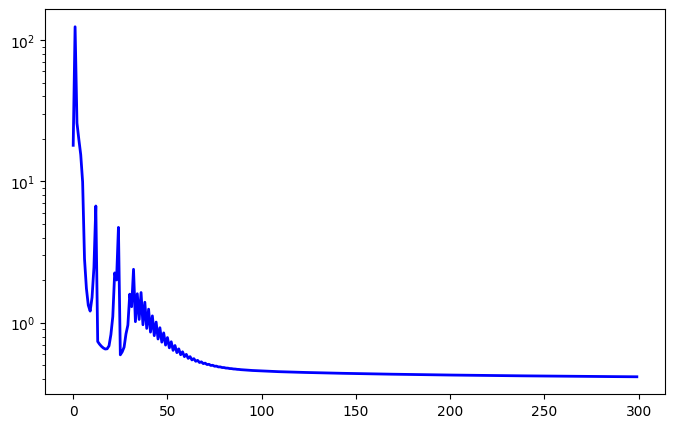

In [ ]:
def init_params(n_in, h1=8, h2=8, seed=None):
    if seed is not None:
        np.random.seed(seed)
    return {
        "W1": np.random.randn(h1, n_in) * np.sqrt(2 / n_in),
        "b1": np.zeros((h1, 1)),
        "W2": np.random.randn(h2, h1) * np.sqrt(2 / h1),
        "b2": np.zeros((h2, 1)),
        "W3": np.random.randn(1, h2) * np.sqrt(2 / h2),
        "b3": np.zeros((1, 1)),
    }


def relu_array(x):
    return np.maximum(0, x)

def activate(x, act):
    return relu_array(x) if act == "relu" else np.tanh(x)

def activate_grad(x, act):
    return np.where(x > 0, 1, 0) if act == "relu" else 1 - np.tanh(x)**2

def forward_prop(X, params, act="relu"):
  W1, b1 = params["W1"], params["b1"]
  W2, b2 = params["W2"], params["b2"]
  W3, b3 = params["W3"], params["b3"]
  z1 = W1 @ X + b1
  a1 = activate(z1, act)
  z2 = W2 @ a1 + b2
  a2 = activate(z2, act)
  z3 = W3 @ a2 + b3
  return z1, a1, z2, a2, z3


def compute_loss(pred, actual):
  L = (1/(2*pred.shape[1])) * np.sum((pred - actual)**2)
  return L


def backprop(X, Y, z1, a1, z2, a2, z3, params, act="relu"):
  W2, W3 = params["W2"], params["W3"]

  # output layer
  dl_dz3 = (z3 - Y) / Y.shape[1]
  dl_dw3 = dl_dz3 @ a2.T
  dl_db3 = np.sum(dl_dz3, axis=1, keepdims=True)

  # layer 2
  dl_da2 = W3.T @ dl_dz3
  da_dz2 = activate_grad(z2, act)
  dl_dz2 = dl_da2 * da_dz2
  dl_dw2 = dl_dz2 @ a1.T
  dl_db2 = np.sum(dl_dz2, axis=1, keepdims=True)

  # layer 1
  dl_da1 = W2.T @ dl_dz2
  da_dz1 = activate_grad(z1, act)
  dl_dz1 = dl_da1 * da_dz1
  dl_dw1 = dl_dz1 @ X.T
  dl_db1 = np.sum(dl_dz1, axis=1, keepdims=True)

  return {
        "W1": dl_dw1, "b1": dl_db1,
        "W2": dl_dw2, "b2": dl_db2,
        "W3": dl_dw3, "b3": dl_db3,
    }


def training_loop(X, Y, params, epochs, lr):
  append_loss = []
  for epoch in range(epochs):
    z1, a1, z2, a2, z3 = forward_prop(X, params)
    get_loss = float(compute_loss(z3, Y))
    append_loss.append(get_loss)
    get_gradients = backprop(X, Y, z1, a1, z2, a2, z3, params)
    for param in params:
      params[param] = params[param] - lr*get_gradients[param]
  plt.figure(figsize=(8, 5))
  plt.plot(append_loss, label='Training Loss', color='blue', linewidth=2)
  plt.yscale('log')
  return append_loss


X_tr = X_train_s.T
Y_tr = y_train.to_numpy().reshape(1, -1)
X_te = X_test_s.T
Y_te = y_test.to_numpy().reshape(1, -1)
print(X_tr.shape, Y_tr.shape)

params = init_params(X_tr.shape[0], h1=64, h2=64, seed=42)
losses = training_loop(X_tr, Y_tr, params, 300, 0.1)
print(losses[0], losses[-1], np.sqrt(2 * losses[-1]))

In [ ]:
_, _, _, _, z3_te = forward_prop(X_te, params)
results['from-scratch NN'] = np.sqrt(2 * compute_loss(z3_te, Y_te))
print(f"from-scratch NN      {results['from-scratch NN']:.4f}")

from-scratch NN      0.9050


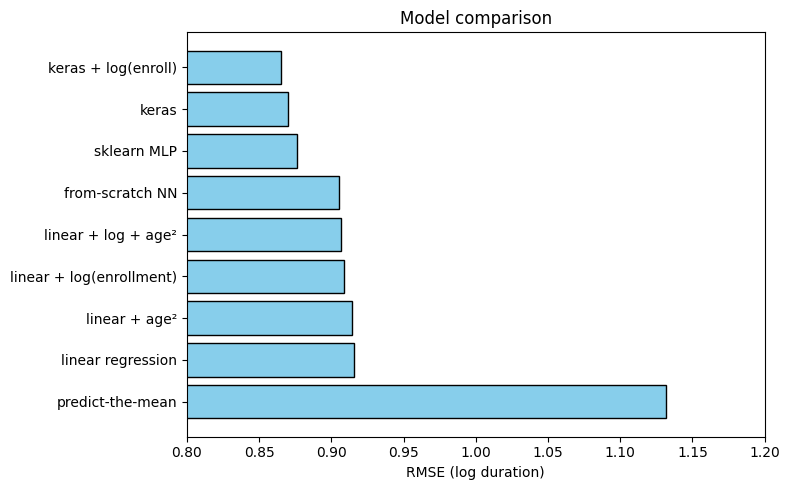

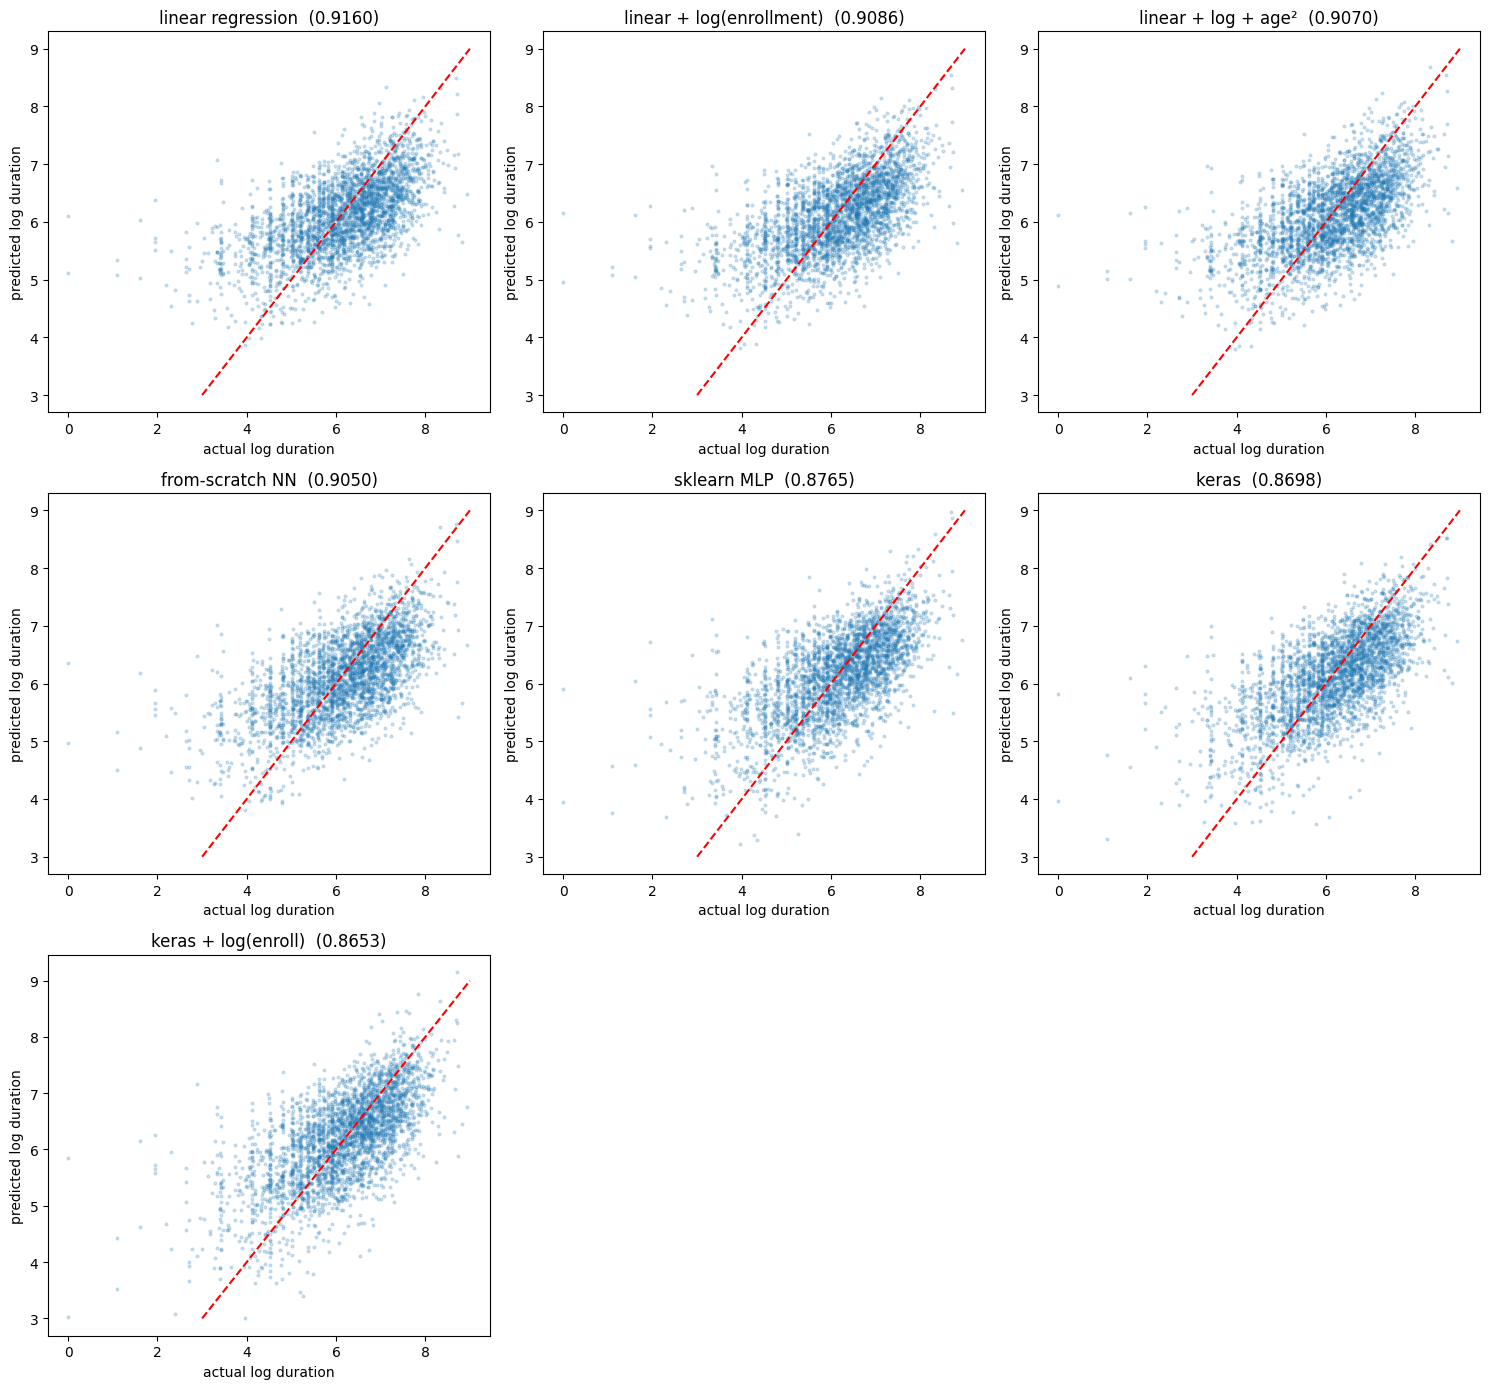

In [ ]:
# ---- model comparison ----
# sorted so the bars read top-to-bottom by performance
ordered = dict(sorted(results.items(), key=lambda kv: kv[1], reverse=True))

plt.figure(figsize=(8, 5))
plt.barh(list(ordered.keys()), list(ordered.values()),
         color='skyblue', edgecolor='black')
plt.xlabel('RMSE (log duration)')
plt.title('Model comparison')
plt.xlim(0.8, 1.2)
plt.tight_layout()
plt.show()


# ---- predicted vs actual, all models ----
preds = {
    'linear regression':    lin.predict(X_test_s),
    'linear + log(enrollment)': lin_log.predict(Xl_test_s),
    'linear + log + age²':  lin_both.predict(Xb_test_s),
    'from-scratch NN':      z3_te.flatten(),
    'sklearn MLP':          mlp.predict(X_test_s),
    'keras':                model.predict(X_test_s, verbose=0).flatten(),
    'keras + log(enroll)':  model_log.predict(Xl_test_s, verbose=0).flatten(),
}

np.random.seed(42)
idx = np.random.choice(len(y_test), 3000, replace=False)
actual = np.array(y_test)[idx]

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
for (name, p), ax in zip(preds.items(), axes.flatten()):
    ax.scatter(actual, np.array(p)[idx], s=4, alpha=0.2)
    ax.plot([3, 9], [3, 9], 'r--')
    ax.set_xlabel('actual log duration')
    ax.set_ylabel('predicted log duration')
    ax.set_title(f"{name}  ({results[name]:.4f})")

for ax in axes.flatten()[len(preds):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Results

Every model beats the baseline by 19% or more, up to 24% for the best one.

The top three are all neural networks, but not by a lot. The best network is
about 5% better than the best linear model. Worth it where small gains matter,
probably not for a planning estimate that is already uncertain by a factor of
2.4x.

Linear regression does a pretty good job on its own. Adding log(enrollment)
and squared age terms closes part of the gap without any network at all.

RMSE here is in log units, so it converts to a multiplier in days:
`exp(0.90) ≈ 2.5`. A prediction of 500 days typically means the truth is
somewhere between 200 and 1,250. That is the same spread the EDA found and no
model narrows it much.

**The from-scratch network lands with the linear models, not the libraries.**
It beats plain linear regression by 1.9%, so it did learn some nonlinearity
that a linear model structurally cannot represent. But the libraries found
considerably more. Since the gradient check passed on all three layers, that
gap is optimizer sophistication rather than an implementation error: 300
full-batch updates against Adam's roughly 27,000 minibatch updates.

**log(enrollment) helps both the linear models and the networks**, by similar
amounts. So the transform and the network are not doing the same job. It also
fixed a training stability problem: on raw enrollment, Keras validation loss
swung between 0.78 and 1.71 across epochs. On log enrollment it stayed between
0.76 and 0.92.

In [ ]:
demo = {
    'from-scratch NN':     (z3_te.flatten(), y_test),
    'keras + log(enroll)': (model_log.predict(Xl_test_s, verbose=0).flatten(), yl_test),
    'linear + log + age²': (lin_both.predict(Xb_test_s), yb_test),
}

# 80% interval: 10th and 90th percentiles of the test residuals. Wider than
# RMSE suggests because it covers the middle 80% rather than a typical error.
bounds = {}
for name, (p, y_true) in demo.items():
    resid = np.array(y_true) - p
    lo, hi = np.percentile(resid, [10, 90])
    bounds[name] = (lo, hi)
    print(f"{name:22s} {lo:+.3f} to {hi:+.3f} log-days   "
      f"(÷{np.exp(-lo):.1f} to ×{np.exp(hi):.1f} in days)")

from-scratch NN        -1.132 to +1.071 log-days   (÷3.1 to ×2.9 in days)
keras + log(enroll)    -1.128 to +0.957 log-days   (÷3.1 to ×2.6 in days)
linear + log + age²    -1.159 to +1.071 log-days   (÷3.2 to ×2.9 in days)


In [ ]:
base = results['predict-the-mean']
for k, v in sorted(results.items(), key=lambda kv: kv[1]):
    print(f"{k:26s} R² = {1 - v**2/base**2:.3f}")

keras + log(enroll)        R² = 0.415
keras                      R² = 0.409
sklearn MLP                R² = 0.400
from-scratch NN            R² = 0.361
linear + log + age²        R² = 0.358
linear + log(enrollment)   R² = 0.355
linear + age²              R² = 0.348
linear regression          R² = 0.345
predict-the-mean           R² = 0.000


The best model (`keras + log(enroll)`) reaches R² = 0.415, leaving 58.5% of the
variance unexplained. This isn't redundancy among the features. The maximum
pairwise correlation is 0.40, so they carry independent information.

Some of the gap is information that doesn't exist at registration: how quickly
sites recruit, whether the protocol gets amended, whether another trial is
competing for the same patients. None of that is knowable on day one, so no
model built on registration data can capture it.

The rest is available in AACT but not extracted here. Geographic detail is
limited to `has_us_facility`, which came free from `calculated_values`. The
`facilities` table has country per site, so a count of distinct countries per
trial would be a natural addition, since regulatory turnaround differs by
jurisdiction and a trial spanning many of them faces many approval processes.
Disease category from the MeSH terms in `browse_conditions` is the other
obvious one, since a rare condition recruits far more slowly than a common one.

In [ ]:
show_cols = ['phase', 'lead_agency_class', 'primary_purpose',
             'enrollment', 'number_of_facilities', 'n_conditions']

meta = df.loc[X_test.index, show_cols]

np.savez(f'{SAVE_DIR}/demo_data.npz',
         y_test=np.array(y_test),
         pred_scratch=z3_te.flatten(),
         pred_keras=model_log.predict(Xl_test_s, verbose=0).flatten(),
         pred_linear=lin_both.predict(Xb_test_s),
         bounds=np.array([bounds['from-scratch NN'],
                          bounds['keras + log(enroll)'],
                          bounds['linear + log + age²']]),
         meta_cols=np.array(show_cols),
         meta=meta.to_numpy().astype(str))